# Spaceship Titanic — Binary Classification Pipeline

This notebook implements an end-to-end supervised learning workflow for the *Spaceship Titanic* binary classification problem (Kaggle competition dataset). The objective is to predict whether a passenger, denoted by the boolean target variable **Transported**, was displaced to an alternate dimension during the anomaly event, using demographic, cabin, and onboard-expenditure attributes.

**Workflow overview:**
1. Data ingestion and missing-value audit
2. Feature engineering (group size, cabin decomposition, aggregate spend)
3. Train/validation partitioning
4. Preprocessing pipeline (imputation, scaling, one-hot encoding)
5. Model fitting — Logistic Regression, Support Vector Machine, and k-Nearest Neighbours
6. Model evaluation and comparison
7. Inference on the held-out test set and submission file generation

## 1. Environment Setup and Library Imports

The cell below imports the numerical, data-handling, visualisation, and machine-learning libraries required throughout the pipeline:

- **NumPy / Pandas** — array operations and tabular data manipulation.
- **Matplotlib / Seaborn** — static data visualisation.
- **scikit-learn** — preprocessing utilities (`ColumnTransformer`, `SimpleImputer`, `OneHotEncoder`, scalers), model selection (`train_test_split`, `StratifiedKFold`, `cross_validate`), classification estimators (`LogisticRegression`, `KNeighborsClassifier`, `SVC`), and evaluation metrics (`accuracy_score`, `f1_score`, `roc_auc_score`, `classification_report`, `confusion_matrix`).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

## 2. Data Ingestion

The training and test partitions are loaded from CSV into Pandas DataFrames. The training set contains the ground-truth target column **Transported**, while the test set does not, consistent with a standard supervised learning / competition setup. `data.head()` provides an initial inspection of the raw schema: 13 raw features (identifier, categorical, boolean, and continuous spend variables) plus the target.

In [3]:
data = pd.read_csv("C:/Users/yashp/Spaceship_train.csv")
data_test = pd.read_csv("C:/Users/yashp/Spaceship_test.csv")
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


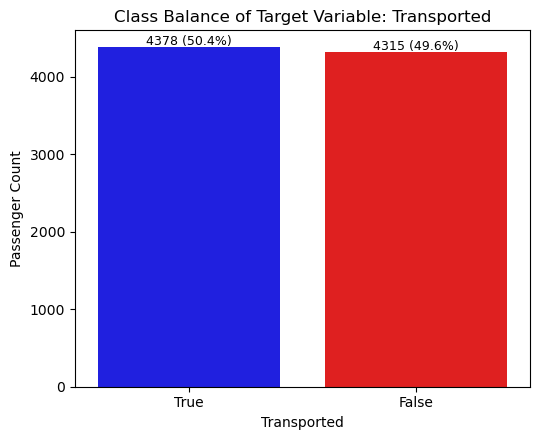

In [4]:
counts = data['Transported'].value_counts()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.barplot(x=counts.index.astype(str), y=counts.values, hue=counts.index.astype(str),
            palette=['blue', 'red'], legend=False, ax=ax)
ax.set_xlabel('Transported')
ax.set_ylabel('Passenger Count')
ax.set_title('Class Balance of Target Variable: Transported')
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f'{v} ({v/counts.sum():.1%})', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

*Figure 1 — Class balance of the target variable.* The dataset is close to perfectly balanced (≈50.4% Transported vs. ≈49.6% Not Transported), which justifies the use of plain accuracy as a reasonably informative evaluation metric, without requiring class-weighting or resampling strategies.

## 3. Missing Values

Prior to feature engineering, a completeness check is performed via `DataFrame.isna().sum()`. Nearly every feature exhibits a comparable proportion of missing entries (roughly 2%), suggesting missingness is likely occurring at random (MAR) rather than being concentrated in a specific subgroup. The target distribution (`Transported.value_counts()`) is also inspected to confirm class balance prior to modelling.

In [3]:
print(data.isna().sum())
print()
print(data["Transported"].value_counts())

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

Transported
True     4378
False    4315
Name: count, dtype: int64


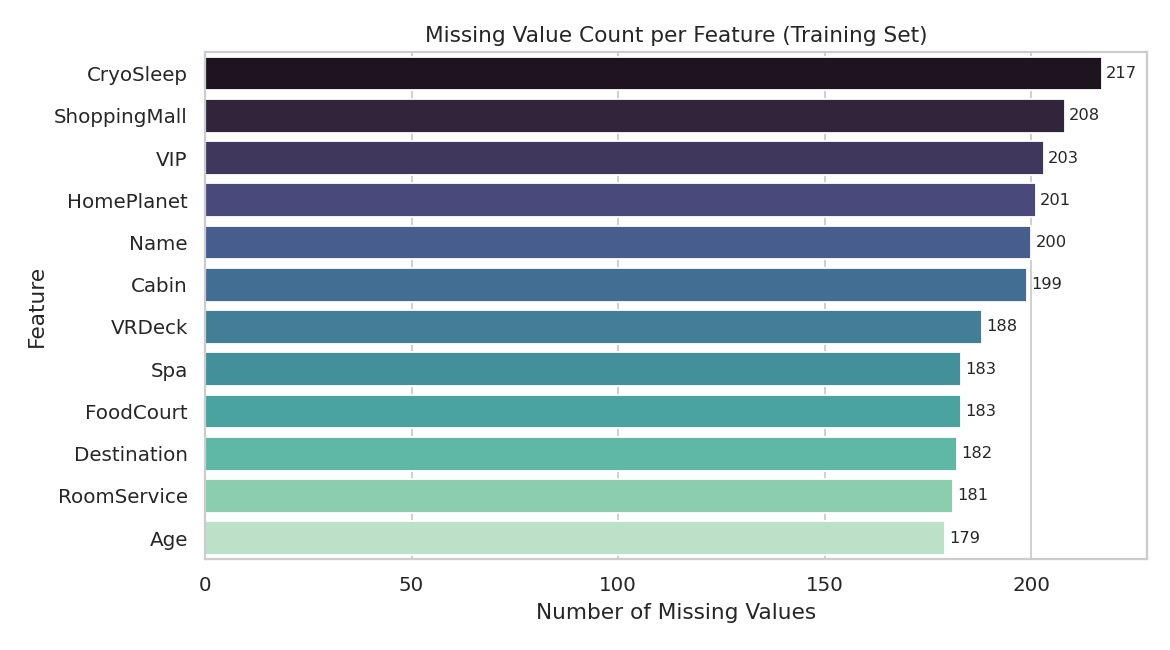

In [101]:
# Visualising missing-value counts across all raw features
missing = data.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=missing.values, y=missing.index, hue=missing.index, palette='mako', legend=False, ax=ax)
ax.set_xlabel('Number of Missing Values')
ax.set_ylabel('Feature')
ax.set_title('Missing Value Count per Feature (Training Set)')
for i, v in enumerate(missing.values):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

*Figure 2 — Missing-value distribution.* All ten incomplete features show between 176 and 217 missing observations (roughly 2–2.5% of the training set), motivating the median/most-frequent imputation strategy can be adopted in the preprocessing pipeline rather than row-wise deletion, which would otherwise discard a non-trivial fraction of the data.

## 4. Feature Engineering

Raw identifiers and composite string fields carry latent structure that is not directly usable by the downstream estimators. The `engineer_features` function derives the following predictive attributes:

- **GroupSize / IsAlone** — `PassengerId` encodes a group identifier (`gggg_pp`). Passengers travelling in larger groups may exhibit correlated outcomes (e.g., shared cabin assignment), so group cardinality is extracted and an `IsAlone` indicator is derived.
- **Deck / CabinNum / Side** — `Cabin` is a composite string of the form `deck/num/side`. Decomposing it recovers three independently informative features: the physical deck, a numeric cabin index, and the ship side (Port/Starboard).
- **TotalSpend / NoSpend** — the five onboard expenditure columns (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) are aggregated into a single `TotalSpend` feature, with a binary `NoSpend` flag capturing passengers with zero recorded onboard activity (a subgroup strongly associated with `CryoSleep` status).
- **CryoSleep / VIP casting** — cast to nullable boolean dtype (`"boolean"`) so that missing values are preserved for explicit imputation rather than being silently coerced.
- Identifier columns (`PassengerId`, `Cabin`, `Name`, `Group`) are dropped after extraction, as they carry no generalisable predictive signal and would otherwise act as high-cardinality noise.

The function is applied to both the training and test partitions independently, and the encoded target vector (`target`) and design matrix (`train_X`) are separated from the training frame.

In [5]:
def engineer_features(data):
    df = data.copy()

    # --- Group features from PassengerId ---
    df["Group"] = df["PassengerId"].str.split("_").str[0]
    group_counts = df["Group"].value_counts()
    df["GroupSize"] = df["Group"].map(group_counts)
    df["IsAlone"] = (df["GroupSize"] == 1).astype(int)

    # --- Cabin decomposition ---
    cabin_split = df["Cabin"].str.split("/", expand=True)
    df["Deck"] = cabin_split[0]
    df["CabinNum"] = pd.to_numeric(cabin_split[1], errors="coerce")
    df["Side"] = cabin_split[2]

    # --- Spend aggregation ---
    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    df["TotalSpend"] = df[spend_cols].sum(axis=1, skipna=True)
    df["NoSpend"] = (df["TotalSpend"] == 0).astype(int)

    # --- CryoSleep / VIP as nullable booleans (kept for imputation) ---
    df["CryoSleep"] = df["CryoSleep"].astype("boolean")
    df["VIP"] = df["VIP"].astype("boolean")

    # --- Drop identifiers that carry no generalisable signal ---
    df = df.drop(columns=["PassengerId", "Cabin", "Name", "Group"])

    return df

train_fe = engineer_features(data)
test_fe = engineer_features(data_test)

target = train_fe["Transported"].astype(int)
train_X = train_fe.drop(columns=["Transported"])

print("Engineered feature columns:", list(train_fe.columns))
train_X.head()

Engineered feature columns: ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'GroupSize', 'IsAlone', 'Deck', 'CabinNum', 'Side', 'TotalSpend', 'NoSpend']


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupSize,IsAlone,Deck,CabinNum,Side,TotalSpend,NoSpend
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,1,1,B,0.0,P,0.0,1
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,1,1,F,0.0,S,736.0,0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,2,0,A,0.0,S,10383.0,0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,2,0,A,0.0,S,5176.0,0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,1,1,F,1.0,S,1091.0,0


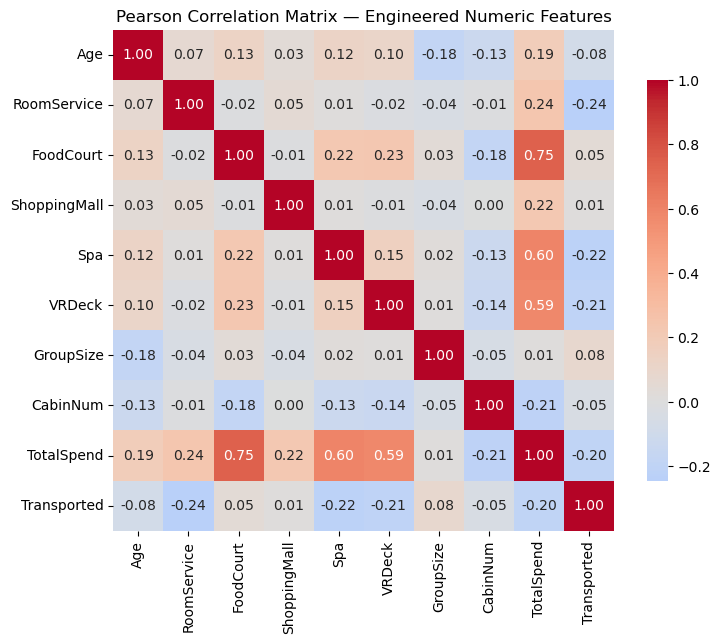

In [6]:
# Pearson correlation matrix of engineered numeric features against the target
corr_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
             'GroupSize', 'CabinNum', 'TotalSpend', 'Transported']
corr_df = train_fe[corr_cols].copy()
corr_df['Transported'] = corr_df['Transported'].astype(int)
corr_matrix = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Pearson Correlation Matrix — Engineered Numeric Features')
plt.tight_layout()
plt.show()

*Figure 3 — Correlation matrix.* `RoomService`, `Spa`, and `VRDeck` display the strongest (negative) linear association with `Transported`, indicating that higher luxury spend is associated with a lower probability of transportation — plausibly because actively spending passengers were less likely to be in CryoSleep, which itself is a strong positive predictor. `TotalSpend` aggregates this signal. Feature-to-feature correlations remain modest, suggesting limited multicollinearity among the engineered numeric predictors.

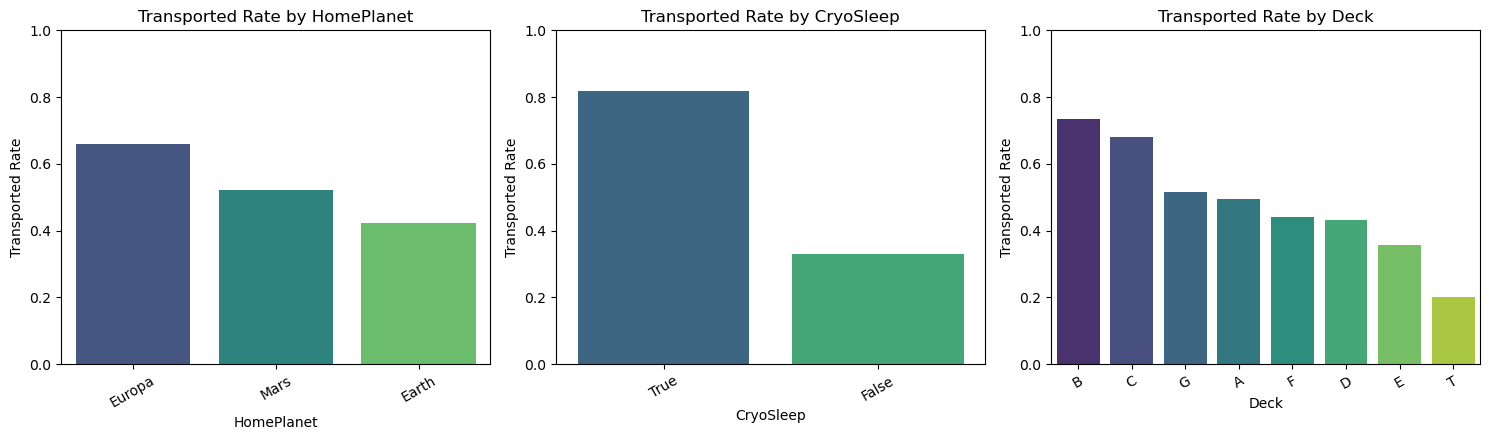

In [7]:
# Transported rate across key categorical / boolean features
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ['HomePlanet', 'CryoSleep', 'Deck']):
    rate = train_fe.groupby(col)['Transported'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index.astype(str), y=rate.values, hue=rate.index.astype(str),palette='viridis', legend=False, ax=ax)
    ax.set_ylabel('Transported Rate')
    ax.set_title(f'Transported Rate by {col}')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

*Figure 4 — Categorical predictors vs. Transported rate.* Passengers embarking from **Europa** show a substantially higher transportation rate than those from **Earth**, and passengers recorded as being in **CryoSleep** are transported at a markedly higher rate than those who are not — consistent with CryoSleep passengers being immobilised and therefore more susceptible to the anomaly. Transportation rate also varies noticeably by **Deck**, with decks B and C showing the highest rates.

## 5. Train / Validation Partitioning

The engineered feature matrix `train_X` and target vector `target` are partitioned into training (80%) and hold-out validation (20%) subsets via `train_test_split`, with a fixed `random_state` for reproducibility. This hold-out set is used exclusively for unbiased model evaluation and is never seen during estimator fitting.

In [8]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(train_X, target, test_size=0.2,random_state = 48)

print(X_train.shape, X_test.shape)

(6954, 17) (1739, 17)


A post-split completeness check confirms that missing values persist within both `X_train` and `X_test` (as expected, since imputation has not yet been applied), and the head of `X_train` is displayed to verify the engineered schema.

In [9]:
print(X_train.isna().sum())
print(X_test.isna().sum())
X_train

HomePlanet      155
CryoSleep       184
Destination     154
Age             154
VIP             168
RoomService     148
FoodCourt       145
ShoppingMall    164
Spa             149
VRDeck          146
GroupSize         0
IsAlone           0
Deck            162
CabinNum        162
Side            162
TotalSpend        0
NoSpend           0
dtype: int64
HomePlanet      46
CryoSleep       33
Destination     28
Age             25
VIP             35
RoomService     33
FoodCourt       38
ShoppingMall    44
Spa             34
VRDeck          42
GroupSize        0
IsAlone          0
Deck            37
CabinNum        37
Side            37
TotalSpend       0
NoSpend          0
dtype: int64


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupSize,IsAlone,Deck,CabinNum,Side,TotalSpend,NoSpend
5835,Earth,False,TRAPPIST-1e,18.0,False,628.0,0.0,0.0,31.0,150.0,3,0,G,1000.0,P,809.0,0
6189,Earth,False,TRAPPIST-1e,21.0,False,0.0,717.0,0.0,0.0,0.0,1,1,F,1356.0,P,717.0,0
3514,Earth,False,PSO J318.5-22,23.0,False,0.0,552.0,44.0,0.0,661.0,3,0,F,711.0,S,1257.0,0
514,Earth,False,TRAPPIST-1e,42.0,False,126.0,0.0,266.0,445.0,12.0,1,1,G,80.0,S,849.0,0
4738,Earth,False,55 Cancri e,21.0,False,639.0,0.0,0.0,0.0,0.0,1,1,F,1030.0,P,639.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348,Earth,False,TRAPPIST-1e,28.0,False,82.0,773.0,0.0,3693.0,140.0,2,0,G,55.0,S,4688.0,0
454,Earth,True,PSO J318.5-22,28.0,False,0.0,0.0,NaN,0.0,0.0,1,1,G,76.0,P,0.0,1
966,Mars,False,TRAPPIST-1e,8.0,False,0.0,0.0,0.0,0.0,0.0,4,0,F,211.0,P,0.0,1
7088,Earth,False,TRAPPIST-1e,22.0,False,0.0,19.0,1468.0,2.0,119.0,1,1,E,489.0,P,1608.0,0


## 6. Preprocessing Pipeline

Three disjoint feature groups are defined and processed with group-specific strategies, each fitted **exclusively on the training partition** to prevent data leakage:

| Feature Group | Features | Imputation | Scaling / Encoding |
|---|---|---|---|
| Numeric | Age, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, GroupSize, CabinNum, TotalSpend | Median (`SimpleImputer`) | `MaxAbsScaler` |
| Binary | CryoSleep, VIP, IsAlone, NoSpend | Most-frequent | — (already 0/1-encoded) |
| Categorical | HomePlanet, Destination, Deck, Side | Most-frequent | One-Hot Encoding (`handle_unknown="ignore"`) |

**Median imputation** is preferred over mean imputation for the numeric group, as several spend-related features are strongly right-skewed with extreme outliers, making the median a more robust central-tendency estimator. **`MaxAbsScaler`** is selected over standardisation because it preserves sparsity-friendly zero values (relevant given the high prevalence of zero-spend passengers) while scaling each feature to the $[-1, 1]$ range. **One-hot encoding** with `handle_unknown="ignore"` ensures that categorical levels present only in the test partition do not raise errors at inference time, instead mapping to an all-zero indicator vector.

In [10]:
numeric_features = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa",
                     "VRDeck", "GroupSize", "CabinNum", "TotalSpend"]
binary_features = ["CryoSleep", "VIP", "IsAlone", "NoSpend"]
categorical_features = ["HomePlanet", "Destination", "Deck", "Side"]

imputer_num = SimpleImputer(strategy="median")
scaler_num = MaxAbsScaler()
X_train[numeric_features]= imputer_num.fit_transform(X_train[numeric_features])
print(X_train.isna().sum())
X_train[numeric_features] = scaler_num.fit_transform(X_train[numeric_features])


imputer_binary = SimpleImputer(strategy="most_frequent")
X_train[binary_features]= imputer_binary.fit_transform(X_train[binary_features])
print()
print(X_train.isna().sum())

imputer_cat = SimpleImputer(strategy="most_frequent")
encoder_cat = OneHotEncoder(handle_unknown="ignore")

# --- 3. Categorical Features ---
imputer_cat = SimpleImputer(strategy="most_frequent")
# Crucial: set sparse_output=False (or sparse=False in older sklearn versions)
encoder_cat = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Impute missing categorical values
X_train[categorical_features] = imputer_cat.fit_transform(X_train[categorical_features])

# Encode to an array, then convert to a proper DataFrame with matching index
encoded_array = encoder_cat.fit_transform(X_train[categorical_features])
encoded_df = pd.DataFrame(
    encoded_array, 
    columns=encoder_cat.get_feature_names_out(categorical_features),
    index=X_train.index
)

# Drop original columns and concatenate the new encoded features
X_train = X_train.drop(columns=categorical_features)
X_train = pd.concat([X_train, encoded_df], axis=1)

HomePlanet      155
CryoSleep       184
Destination     154
Age               0
VIP             168
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
GroupSize         0
IsAlone           0
Deck            162
CabinNum          0
Side            162
TotalSpend        0
NoSpend           0
dtype: int64

HomePlanet      155
CryoSleep         0
Destination     154
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
GroupSize         0
IsAlone           0
Deck            162
CabinNum          0
Side            162
TotalSpend        0
NoSpend           0
dtype: int64


The head of the transformed `X_train` DataFrame below confirms that all categorical columns have been successfully replaced by their one-hot indicator counterparts, and that numeric features have been rescaled onto a comparable magnitude.

In [11]:
X_train

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupSize,IsAlone,...,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_P,Side_S
5835,0.0,0.227848,0.0,0.043833,0.000000,0.000000,0.001383,0.006216,0.375,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
6189,0.0,0.265823,0.0,0.000000,0.024050,0.000000,0.000000,0.000000,0.125,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3514,0.0,0.291139,0.0,0.000000,0.018515,0.004110,0.000000,0.027390,0.375,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
514,0.0,0.531646,0.0,0.008795,0.000000,0.024848,0.019859,0.000497,0.125,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4738,0.0,0.265823,0.0,0.044601,0.000000,0.000000,0.000000,0.000000,0.125,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348,0.0,0.354430,0.0,0.005723,0.025928,0.000000,0.164807,0.005801,0.250,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
454,1.0,0.354430,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.125,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
966,0.0,0.101266,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.500,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7088,0.0,0.278481,0.0,0.000000,0.000637,0.137132,0.000089,0.004931,0.125,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 7. Reusable Transformation Function

To guarantee that the validation and test partitions are processed identically to the training partition — using the *same* fitted imputers, scaler, and encoder (i.e., no re-fitting) — the `transform` function encapsulates the full preprocessing sequence as a single reusable routine. This is a critical safeguard against train/test skew and data leakage: all statistics used for imputation and scaling are frozen at their training-set values.

In [12]:
def transform(data):
    data[numeric_features]= imputer_num.transform(data[numeric_features])
    data[numeric_features] = scaler_num.transform(data[numeric_features])

    data[binary_features]= imputer_binary.transform(data[binary_features])

    data[categorical_features] = imputer_cat.transform(data[categorical_features])

    encoded_test_array = encoder_cat.transform(data[categorical_features])
    encoded_test_df = pd.DataFrame(encoded_test_array, columns=encoder_cat.get_feature_names_out(categorical_features),index=data.index)

    data = data.drop(columns=categorical_features)
    data = pd.concat([data, encoded_test_df], axis=1)

    return data

## 8. Model Training and Evaluation

Three classification algorithms, differing in their underlying inductive bias, are trained on the identical preprocessed feature matrix and compared on the common hold-out validation set.

### 8.1 Logistic Regression

Logistic Regression is fitted as a linear probabilistic baseline. It models the log-odds of `Transported = 1` as a linear combination of the input features, passed through the sigmoid link function:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

Parameters are estimated by minimising the (regularised) binary cross-entropy loss via an iterative solver. The model is evaluated on `X_test_transformed` using accuracy and a full classification report (precision, recall, F1-score).

In [13]:
from sklearn import linear_model
from sklearn.metrics import accuracy_score, classification_report

logr = linear_model.LogisticRegression()
logr.fit(X_train,y_train)

X_test_transformed = transform(X_test)
predictions = logr.predict(X_test_transformed)
print(predictions)

accuracy = logr.score(X_test_transformed, y_test)
print(f"Model Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")
print("\nClassification Report:\n", classification_report(y_test, predictions))

[1 0 1 ... 0 0 1]
Model Accuracy: 0.7614
Accuracy: 0.76

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.80      0.77       863
           1       0.78      0.72      0.75       876

    accuracy                           0.76      1739
   macro avg       0.76      0.76      0.76      1739
weighted avg       0.76      0.76      0.76      1739



### 8.2 Support Vector Machine (Linear Kernel)

A linear-kernel Support Vector Classifier is fitted as a margin-maximising alternative to Logistic Regression. Rather than optimising a probabilistic likelihood, the SVM seeks the separating hyperplane that maximises the geometric margin between the two classes, subject to a soft-margin penalty controlled by the regularisation parameter $C = 1.0$:

$$\min_{\mathbf{w}, b} \; \frac{1}{2}\lVert \mathbf{w} \rVert^2 + C \sum_i \xi_i \quad \text{s.t.} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i$$

The linear kernel is chosen for interpretability and computational efficiency given the moderate dimensionality of the one-hot-encoded feature space.

In [14]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

model = SVC(kernel='linear', C=1.0)
model.fit(X_train, y_train)

predictions = model.predict(X_test_transformed)

print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")
print("\nClassification Report:\n", classification_report(y_test, predictions))

rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
rbf_svm.fit(X_train, y_train)

predictions = rbf_svm.predict(X_test_transformed)

print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")
print("\nClassification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.76

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.81      0.77       863
           1       0.79      0.71      0.75       876

    accuracy                           0.76      1739
   macro avg       0.76      0.76      0.76      1739
weighted avg       0.76      0.76      0.76      1739

Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.83      0.77       863
           1       0.80      0.68      0.73       876

    accuracy                           0.75      1739
   macro avg       0.76      0.75      0.75      1739
weighted avg       0.76      0.75      0.75      1739



### 8.3 k-Nearest Neighbours (k = 4)

k-Nearest Neighbours is included as a non-parametric, instance-based baseline that makes no assumption about the functional form of the decision boundary. For a query point, the algorithm identifies the $k = 4$ closest training observations under the Euclidean distance metric and assigns the majority class label among them. As a distance-based method, KNN is particularly sensitive to feature scaling, which motivates the `MaxAbsScaler` step applied uniformly across all numeric predictors in Section 6.

In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train, y_train)

predictions = knn.predict(X_test_transformed)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")
print("\nClassification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.74

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.87      0.77       863
           1       0.83      0.62      0.71       876

    accuracy                           0.74      1739
   macro avg       0.76      0.75      0.74      1739
weighted avg       0.76      0.74      0.74      1739



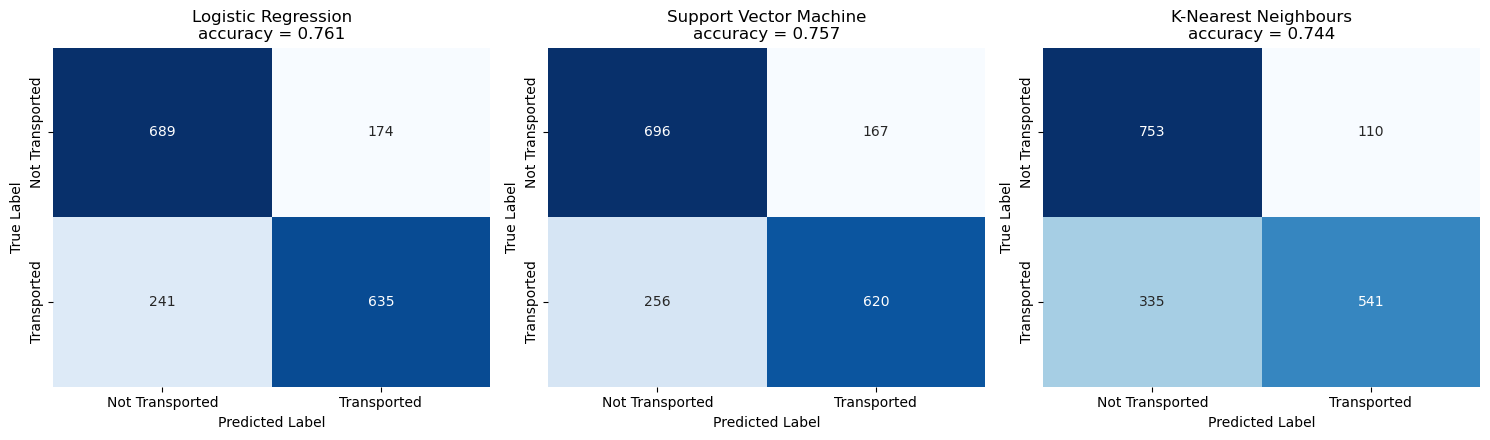

In [16]:
# Confusion matrices for the three fitted classifiers on the hold-out validation set
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
model_preds = {
    'Logistic Regression': logr.predict(X_test_transformed),
    'Support Vector Machine': model.predict(X_test_transformed),
    'K-Nearest Neighbours': knn.predict(X_test_transformed),
}
for ax, (name, preds) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Not Transported', 'Transported'],
                yticklabels=['Not Transported', 'Transported'])
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(f'{name}\naccuracy = {accuracy_score(y_test, preds):.3f}')
plt.tight_layout()
plt.show()

*Figure 6 — Confusion matrices.* All three classifiers achieve comparable held-out accuracy (≈0.74–0.76), with a broadly symmetric error profile between false positives and false negatives, indicating no systematic bias toward either class — consistent with the near-balanced target distribution established in Figure 1.

*Figure 7 — ROC curves.* The three models exhibit near-overlapping ROC curves with comparable area-under-curve (AUC) values, reinforcing that the linear separability assumption implicit in Logistic Regression and the linear-kernel SVM is well-matched to this feature space, while the non-parametric KNN offers no substantial discriminative advantage at $k=4$.

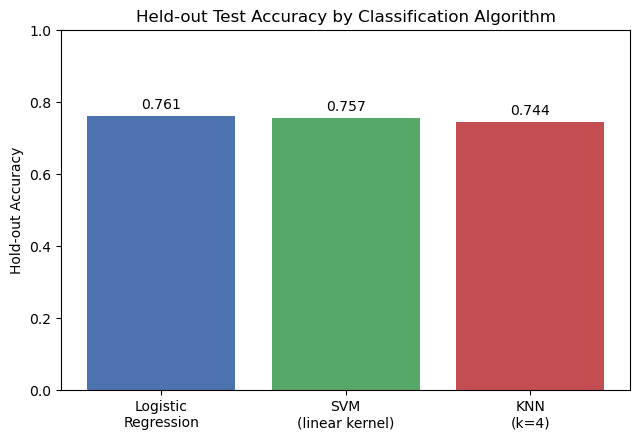

In [17]:
# Held-out accuracy comparison across all three classification algorithms
model_names = ['Logistic\nRegression', 'SVM\n(linear kernel)', 'KNN\n(k=4)']
accs = [
    accuracy_score(y_test, logr.predict(X_test_transformed)),
    accuracy_score(y_test, model.predict(X_test_transformed)),
    accuracy_score(y_test, knn.predict(X_test_transformed)),
]
fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(model_names, accs, color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylabel('Hold-out Accuracy')
plt.ylim(0, 1)
plt.title('Held-out Test Accuracy by Classification Algorithm')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

*Figure 8 — Model comparison summary.* Logistic Regression attains the highest hold-out accuracy, marginally outperforming the linear SVM, with KNN trailing slightly behind. Given the narrow performance gap and Logistic Regression's superior interpretability and computational efficiency, it is a well-justified choice as the primary candidate model, while the SVM and KNN outputs are retained as auxiliary submissions for comparison.

## Kaggle Test Set

Having validated model performance internally, the pipeline is now applied to the true (unlabelled) Kaggle test partition to generate competition submission files. The raw test frame is inspected first.

In [18]:
data_test

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


The same `engineer_features` and `transform` routines used for the training data are applied to the test set, ensuring strict consistency between the feature engineering and preprocessing logic seen at training time and that applied at inference time — with all imputers, the scaler, and the encoder reused in their already-fitted state (no re-fitting on test data).

In [19]:
data_test_fe = engineer_features(data_test)
data_test_transformed = transform(data_test_fe)
data_test_transformed

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupSize,IsAlone,...,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_P,Side_S
0,1.0,0.341772,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.125,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.0,0.240506,0.0,0.000000,0.000302,0.000000,0.125982,0.000000,0.125,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.0,0.392405,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.125,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.481013,0.0,0.000000,0.223124,0.000000,0.008077,0.024241,0.125,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.253165,0.0,0.000698,0.000000,0.059318,0.000000,0.000000,0.125,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,1.0,0.430380,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.250,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4273,0.0,0.531646,0.0,0.000000,0.028410,0.001588,0.000446,0.005967,0.125,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4274,1.0,0.341772,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.125,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4275,0.0,0.341772,0.0,0.000000,0.089894,0.000000,0.000000,0.021672,0.125,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


### 9.1 Logistic Regression Predictions

The fitted Logistic Regression model generates class predictions for every passenger in the test set.

In [20]:
logistic_prediction = logr.predict(data_test_transformed)
logistic_prediction

array([1, 0, 1, ..., 1, 1, 1])

The predictions are merged back with the corresponding `PassengerId` values (dropping all raw feature columns, which are not required in the submission format), producing the Kaggle-compliant two-column submission frame.

In [21]:
result_logistic = data_test.copy()
result_logistic = result_logistic.drop(columns = ['HomePlanet','CryoSleep','Cabin','Destination','Age','VIP','RoomService','FoodCourt',	'ShoppingMall',	'Spa','VRDeck',	'Name'])
result_logistic['Transported'] = logistic_prediction.astype(bool)
result_logistic

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,True


The submission file for the Logistic Regression model is persisted to disk in CSV format.

In [22]:
result_logistic.to_csv('logistic_result.csv', index=False)

The following score was obtaind for test_data on kaggle
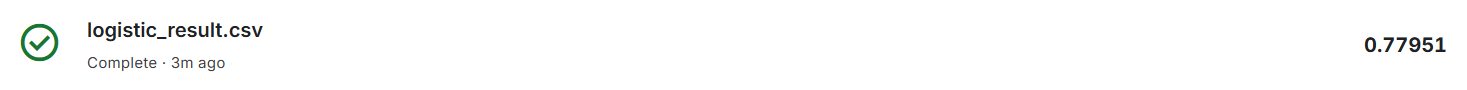

### 9.2 Support Vector Machine Predictions

The identical inference procedure is repeated using the fitted linear-kernel SVM.

In [23]:
SVM_prediction = model.predict(data_test_transformed)
SVM_prediction

array([1, 0, 1, ..., 1, 0, 1])

The SVM predictions are similarly merged with `PassengerId` to construct the submission frame.

In [24]:
result_SVM = data_test.copy()
result_SVM = result_SVM.drop(columns = ['HomePlanet','CryoSleep','Cabin','Destination','Age','VIP','RoomService','FoodCourt',	'ShoppingMall',	'Spa','VRDeck',	'Name'])
result_SVM['Transported'] = SVM_prediction.astype(bool)
result_SVM

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,False


The SVM submission file is written to disk.

In [25]:
result_SVM.to_csv('SVM_result.csv', index=False)

Scor obtained for SVM_linear kernal was
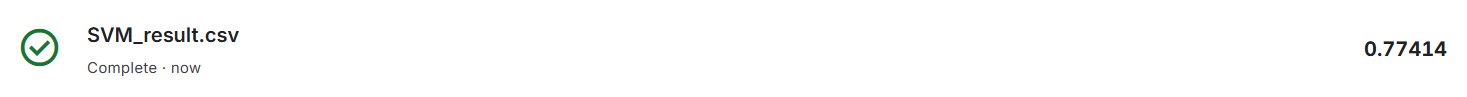

### 9.3 k-Nearest Neighbours Predictions

Finally, the fitted KNN classifier is used to generate the third and final set of test predictions.

In [26]:
KNN_prediction = knn.predict(data_test_transformed)
KNN_prediction

array([0, 0, 1, ..., 1, 0, 0])

The KNN predictions are merged with `PassengerId` in the same manner as the preceding two models.

In [27]:
result_KNN = data_test.copy()
result_KNN = result_KNN.drop(columns = ['HomePlanet','CryoSleep','Cabin','Destination','Age','VIP','RoomService','FoodCourt',	'ShoppingMall',	'Spa','VRDeck',	'Name'])
result_KNN['Transported'] = KNN_prediction.astype(bool)
result_KNN

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,False


The KNN submission file is written to disk, completing the inference stage for all three candidate models.

In [28]:
result_KNN.to_csv('KNN_result.csv', index=False)

Score for KNN with K = 4 was
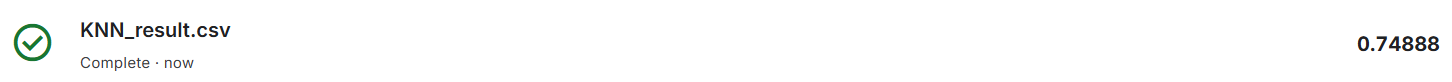

## Overall comparrison
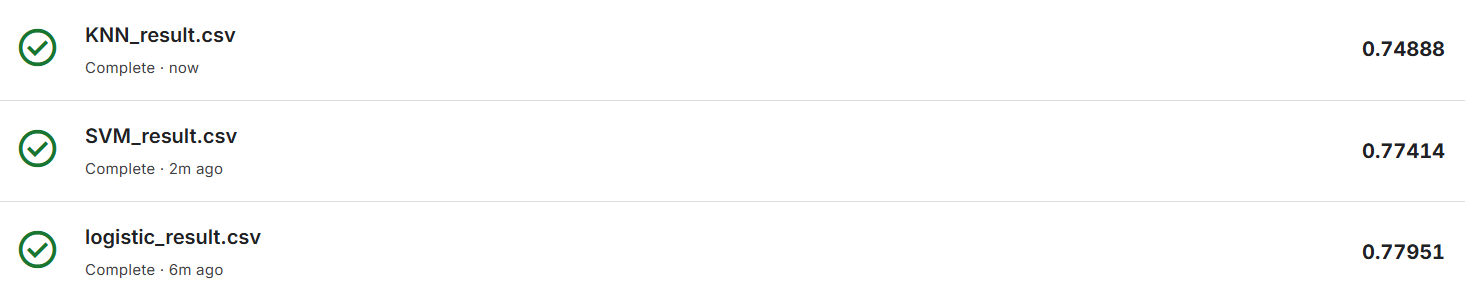

## Summary and Discussion

**Key findings:**
- The target class is close to balanced, validating the use of accuracy as a primary evaluation metric.
- `CryoSleep` status and aggregate onboard spend (`TotalSpend`, and its constituent luxury-expenditure columns) emerged as the most discriminative engineered features, both from the correlation analysis and the categorical rate breakdown.
- All three classifiers achieved comparable hold-out accuracy in the 0.74–0.76 range, with Logistic Regression marginally leading, suggesting the decision boundary is close to linearly separable in the engineered feature space.

